# Online Retail – Customer Churn Detection

## 1. Problem Definition

Customer churn refers to customers who discontinue their purchasing behavior over time. In non-subscription online retail settings, churn is not directly observable and must be inferred from customer inactivity.

In this project, churn is defined using a **forward-looking 90-day observation window**. Specifically, a customer is labeled as churned if they do not make any purchase within the 90 days following a defined cutoff date.

To simulate a real-world prediction scenario, a **time-based split** is applied:

* **Feature window:** Historical transactional data prior to the cutoff date is used to compute customer-level features.
* **Label window:** Customer activity in the subsequent 90-day period is used to determine churn labels.

The objective is to build a supervised machine learning model that predicts the likelihood of future customer churn based on historical behavior.

Customer behavior is summarized using **RFM (Recency, Frequency, Monetary)** features:

* **Recency:** Time since the last purchase
* **Frequency:** Number of unique transactions
* **Monetary:** Total spending

These features capture customer engagement and value, which are strong indicators of churn risk.

Given the expected class imbalance in churn prediction, model performance will be evaluated using appropriate metrics such as **ROC-AUC, Precision, Recall, and F1-score**, with particular emphasis on correctly identifying churned customers (Recall).


## 2. Data Loading
I load the raw transaction data to verify that it contains the essential fields (customer ID and dates) needed to build a behavioral churn definition for online retail.

In [1]:
import pandas as pd

# Read csv dataset
retail_df = pd.read_csv("online_retail.csv")

# Basic data quality checks
print(retail_df.shape)
print(retail_df.head())

(541909, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


## 3. Data Cleaning

The objective of this step is to create a clean and consistent transactional dataset suitable for customer-level churn analysis.

Missing customer IDs are removed, as they prevent aggregation of transactions at the customer level. Transactions with non-positive quantities or unit prices are excluded, as they represent returns or data inconsistencies that could distort customer behavior patterns. Additionally, canceled invoices (identified by invoice numbers starting with 'C') are removed to retain only completed purchases.

The `InvoiceDate` column is converted to datetime format to enable time-based analysis, which is essential for churn definition. A `TotalPrice` feature is created as the product of quantity and unit price to capture the monetary value of each transaction.

The cleaned dataset remains at the transaction level and will be aggregated to the customer level in the next step for RFM feature engineering.
 

In [2]:
# Convert to datetime early
retail_df['InvoiceDate'] = pd.to_datetime(retail_df['InvoiceDate'])

# Remove missing customers
retail_df = retail_df.dropna(subset=['CustomerID'])

# Remove duplicates
retail_df = retail_df.drop_duplicates()

# Remove invalid transactions
retail_df = retail_df[(retail_df['Quantity'] > 0) & (retail_df['UnitPrice'] > 0)]

# Remove cancellations
retail_df = retail_df[~retail_df['InvoiceNo'].astype(str).str.startswith('C')]

# Create total price
retail_df['TotalPrice'] = retail_df['Quantity'] * retail_df['UnitPrice']

# Sanity checks
print("Shape:", retail_df.shape)
print("Unique customers:", retail_df['CustomerID'].nunique())

Shape: (392692, 9)
Unique customers: 4338


After cleaning, the dataset contains 392,692 valid transactions across 4,338 unique customers, providing a reliable foundation for customer-level analysis and churn modeling.


## 4. Exploratory Data Analysis (EDA)

### 4.1. EDA(1)

Identify the most active countries in the dataset to decide whether churn analysis should be focused on a single market (UK) or segmented by geography.

In [3]:
# Top countries by transactions
print(retail_df['Country'].value_counts().head())

uk_pct = retail_df['Country'].value_counts(normalize=True)['United Kingdom'] * 100
print(f"UK share: {uk_pct:.2f}%")

United Kingdom    349203
Germany             9025
France              8326
EIRE                7226
Spain               2479
Name: Country, dtype: int64
UK share: 88.93%


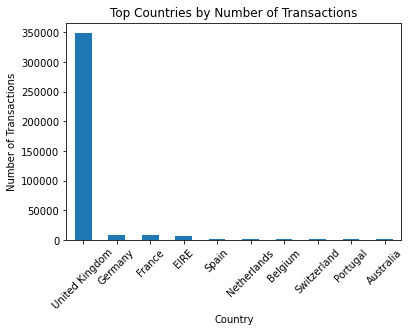

In [4]:
import matplotlib.pyplot as plt

retail_df['Country'].value_counts().head(10).plot(kind='bar')
plt.title("Top Countries by Number of Transactions")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()

The dataset is heavily dominated by transactions from the United Kingdom, accounting for approximately 89% of all records.

Including countries with very low transaction volumes may lead to unreliable patterns and poor generalization, as customer behavior in these regions is underrepresented.

Therefore, the analysis is restricted to UK customers to ensure sufficient data coverage and more robust churn modeling.

While an alternative approach could involve modeling each country separately or including country as a feature, focusing on the UK simplifies the analysis and improves consistency in customer behavior patterns.

### 4.2. EDA(2)

Analyze the monthly sales trend to understand overall business seasonality and to identify a stable time window for defining churn.

In [5]:
# Monthly sales trend
monthly_sales = retail_df.groupby(retail_df['InvoiceDate'].dt.to_period('M'))['TotalPrice'].sum()
monthly_sales

InvoiceDate
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: TotalPrice, dtype: float64

The monthly sales trend shows a clear upward pattern throughout 2011, with a significant peak in November followed by a sharp decline in December.

This pattern suggests strong seasonality, likely driven by holiday-related demand. As a result, short-term inactivity may not necessarily indicate churn but rather seasonal purchasing behavior.

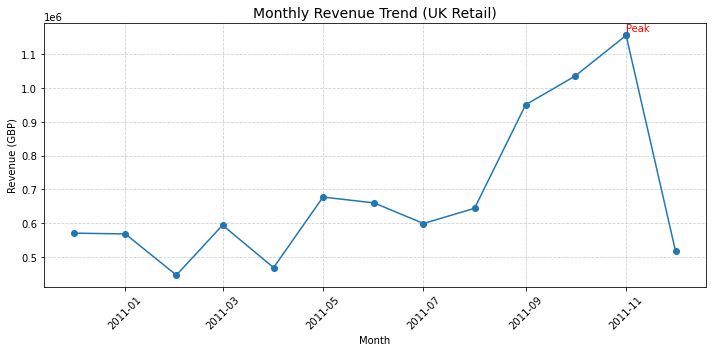

In [6]:
import matplotlib.pyplot as plt

monthly_sales = retail_df.groupby(retail_df['InvoiceDate'].dt.to_period('M'))['TotalPrice'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()

plt.figure(figsize=(10,5))

plt.plot(monthly_sales.index, monthly_sales.values, marker='o')

max_idx = monthly_sales.idxmax()
max_val = monthly_sales.max()

plt.scatter(max_idx, max_val, color='red')
plt.text(max_idx, max_val * 1.01, 'Peak', color='red')

plt.title('Monthly Revenue Trend (UK Retail)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Revenue (GBP)')

plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


   - The monthly sales trend exhibits strong seasonality, with noticeable peaks and drops in demand.

   - Therefore, churn should be defined using a sufficiently long inactivity window (e.g., 90 days) to avoid misclassifying seasonal customers as churned.

## 5. Data Filtering (UK Customers Only)

Based on exploratory analysis, the dataset is heavily dominated by transactions from the United Kingdom (approximately 89%), while other countries contribute relatively sparse data.

To ensure consistent customer behavior patterns and improve model reliability, the analysis is restricted to UK customers only.

This filtering step is applied prior to the time-based split, ensuring that both training and future (label) data are drawn from a consistent and homogeneous customer population.

In [7]:
uk_customers = retail_df[retail_df['Country'] == 'United Kingdom']['CustomerID'].unique()

uk_customers = uk_customers.tolist()

retail_df = retail_df[retail_df['Country'] == 'United Kingdom']

print(retail_df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalPrice  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom       15.30  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom       22.00  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34  


This approach reduces noise from underrepresented regions and leads to more reliable churn predictions.

## 6. Time-based Split

To ensure a realistic and unbiased evaluation of the churn prediction model, a time-based split is applied instead of a random split.

A cutoff date of September 1, 2011 is selected to divide the dataset into a **feature window** and a **label (future) window**:

* **Feature window:** All transactions before the cutoff date are used to compute customer-level features.
* **Label window:** Transactions occurring within 90 days after the cutoff date are used to determine churn labels.


This approach simulates a real-world scenario where models are trained on historical data and used to predict future customer behavior, while preventing data leakage.

The cutoff date is chosen to ensure sufficient data in both periods while preserving the temporal ordering of customer behavior.

The feature and label windows are strictly separated in time to ensure that no future information is used during model training.


In [9]:
cutoff_date = pd.to_datetime('2011-09-01')

# Create training dataset using transactions before the cutoff date
train_df = retail_df[retail_df['InvoiceDate'] < cutoff_date].copy()

# Define a 90-day future window after the cutoff date to capture customer behavior
# and extract transactions in this period (used for labeling or test dataset)
label_end_date = pd.to_datetime(cutoff_date) + pd.Timedelta(days=90)

label_df = retail_df[
    (retail_df['InvoiceDate'] >= cutoff_date) &
    (retail_df['InvoiceDate'] < label_end_date)
].copy()

print("Train shape:", train_df.shape)

Train shape: (197948, 9)


## 7. Feature Engineering – RFM

RFM (Recency, Frequency, Monetary) is a widely used customer behavior framework in marketing analytics that summarizes purchasing patterns using three key dimensions: how recently a customer made a purchase, how often they purchase, and how much they spend. These features provide a compact and interpretable representation of customer value and engagement, and are commonly used for customer segmentation, churn analysis, and targeted marketing.


The snapshot date is defined as one day after the last transaction in the training dataset to ensure that recency is calculated consistently for all customers.

All RFM features are computed exclusively using transactions from the feature window (i.e., before the cutoff date) to prevent data leakage from future information.


In [10]:
# Compute snapshot date as one day after the last transaction in the training data
# This ensures consistent recency calculation and avoids zero-day values
snapshot_date = train_df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Aggregate transactional data at the customer level to construct RFM features
# Only transactions before the cutoff date are used to prevent data leakage
rfm = train_df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

# Rename columns for clarity and standard RFM naming
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,226,1,77183.60
1,12747.0,10,8,2769.40
2,12748.0,2,127,13339.05
3,12749.0,31,3,2755.23
4,12820.0,227,1,170.46


RFM features are constructed by aggregating customer transactions within the feature window (before the cutoff date) to prevent data leakage. A snapshot date is set as one day after the last transaction to ensure consistent recency calculation.

   - Recency: days since the most recent purchase

   - Frequency: number of unique transactions

   - Monetary: total customer spending

These features provide a compact representation of customer behavior and are widely used for churn modeling. The dataset captures historical behavior up to the cutoff date to predict churn in the following 90-day period, where recently active, frequent, and high-spending customers are less likely to churn.

## 8. Churn Labeling

In this phase, the churn label is defined using a forward-looking approach based on customer activity in the future (label) window.

Customers are labeled as churned (1) if they do not make any purchase during the 90-day period following the cutoff date. Conversely, customers who make at least one purchase in this period are considered active (0).

This definition aligns with a real-world prediction setting, where the goal is to identify customers who are likely to become inactive in the future based on their historical behavior.

The churn label is constructed by checking whether each customer in the feature dataset appears in the future transaction data.

In [11]:
future_customers = label_df['CustomerID'].unique()

rfm['Churn'] = (~rfm['CustomerID'].isin(future_customers)).astype(int)

### 8.1. Churn Distribution
To analyze class balance, the distribution of the churn label is examined:

In [12]:
rfm['Churn'].value_counts(normalize=True)

0    0.560723
1    0.439277
Name: Churn, dtype: float64

The dataset shows a moderate class imbalance, with approximately 44% churned customers and 56% active customers. Although the class imbalance is moderate, it may still impact model performance, particularly for recall-sensitive use cases such as churn detection.


The distribution of the churn label is visualized to better understand class imbalance, which can impact model performance and evaluation.


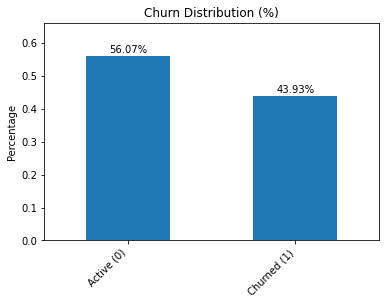

In [13]:
dist = rfm['Churn'].value_counts(normalize=True).sort_index()

ax = dist.plot(kind='bar')

for i, v in enumerate(dist):
    ax.text(i, v + 0.01, f"{v:.2%}", ha='center')


plt.ylim(0, dist.max() + 0.1)

plt.ylabel('Percentage') 

ax.set_xticklabels(['Active (0)', 'Churned (1)'], rotation=45, ha='right')

plt.title('Churn Distribution (%)')
plt.show()

This level of imbalance is manageable but should be considered during modeling. Appropriate evaluation metrics such as ROC-AUC, Precision-Recall, and F1-score will be used, and techniques such as class weighting may be applied if necessary.

## 9. Feature Scaling

In this step, the dataset is prepared for predictive modeling. The RFM features (Recency, Frequency, and Monetary) are selected as input variables, while the churn indicator is used as the target variable.

Feature scaling is applied using standardization to ensure that all input variables contribute equally to the model. The scaler is fitted on the training data and then applied to the validation set to prevent data leakage.

Since a time-based split has already been performed, a validation split is created within the training data to enable model evaluation and tuning.


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features & target
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Churn']

# Validation split (only for train data)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

# Check shapes
print(X_train_scaled.shape, X_val_scaled.shape)
print(y_train.value_counts(normalize=True))
print(y_val.value_counts(normalize=True))

(2391, 3) (598, 3)
0    0.560853
1    0.439147
Name: Churn, dtype: float64
0    0.560201
1    0.439799
Name: Churn, dtype: float64


## 10. Model Training & Comparison

In this section, two machine learning models are trained and evaluated using relevant performance metrics such as ROC-AUC, precision, and recall. Given the class imbalance in churn data, particular emphasis is placed on metrics that capture the model’s ability to correctly identify churned customers. The objective is to select the most reliable model for churn prediction.

### 10.1. Logistic Regression

As a first ML approach, Logistic Regression is used for churn detection. Logistic Regression a supervised machine learning algorithm used for classification problems. Unlike linear regression, which predicts continuous values, it predicts the probability that an input belongs to a specific class. 

The model configured with `max_iter=1000` and ` class_weight=’balanced’` that uses the values of y to automatically adjust weights inversely proportional to class frequencies in the input data as `n_samples / (n_classes * np.bincount(y))`.

The logestic regression model is triand on scaled data to converge better and achieve better accuracy.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Train
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = lr_model.predict(X_val_scaled)
y_proba_lr = lr_model.predict_proba(X_val_scaled)[:, 1]

# Evaluation
print("Logistic Regression")
print(classification_report(y_val, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_val, y_proba_lr))

Logistic Regression
              precision    recall  f1-score   support

           0       0.82      0.59      0.68       335
           1       0.61      0.84      0.71       263

    accuracy                           0.70       598
   macro avg       0.72      0.71      0.70       598
weighted avg       0.73      0.70      0.70       598

ROC-AUC: 0.759605016741388


### 10.2. Random Forest


In this step, a Random Forest classifier is used to train a churn prediction model. Random Forest is an ensemble learning method that builds multiple decision trees and combines their predictions to improve robustness and reduce overfitting.

The model is configured with 300 trees `n_estimators=300` to ensure stable and reliable predictions. The maximum depth of each tree is limited to 8 `max_depth=8` in order to control model complexity and prevent overfitting. Since churn datasets are typically imbalanced, the parameter `class_weight='balanced'` is applied so that the model assigns higher importance to the minority class (churned customers).

A fixed random seed `random_state=42` is used to ensure reproducibility of results. Finally, the model is trained using the scaled training features `X_train` and the corresponding churn labels `y_train`.

- Random Forest handles non-linear relationships well, is robust to noise, and performs effectively on tabular business data such as RFM features.

In [17]:
from sklearn.ensemble import RandomForestClassifier

# Train
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)  # without scaling

# Predict
y_pred_rf = rf_model.predict(X_val)
y_proba_rf = rf_model.predict_proba(X_val)[:, 1]

# Evaluation
print("\nRandom Forest")
print(classification_report(y_val, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_val, y_proba_rf))


Random Forest
              precision    recall  f1-score   support

           0       0.77      0.61      0.68       335
           1       0.61      0.76      0.68       263

    accuracy                           0.68       598
   macro avg       0.69      0.69      0.68       598
weighted avg       0.70      0.68      0.68       598

ROC-AUC: 0.7519210033482776


### 10.3. Evaluation

To evaluate model performance, both Logistic Regression and Random Forest classifiers are trained and compared. Logistic Regression provides a simple and interpretable baseline, while Random Forest captures non-linear relationships in the data.

Given the class imbalance and business objective of identifying at-risk customers, evaluation focuses on metrics such as ROC-AUC and recall.

Feature scaling is applied for Logistic Regression, while Random Forest is trained on the original features, as tree-based models are not sensitive to feature magnitude.


In [23]:
from sklearn.metrics import recall_score

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'ROC-AUC': [
        roc_auc_score(y_val, y_proba_lr),
        roc_auc_score(y_val, y_proba_rf)
    ],
    'Recall': [recall_lr, recall_rf]
})

print(results)

recall_lr = recall_score(y_val, y_pred_lr)
recall_rf = recall_score(y_val, y_pred_rf)

print("Recall LR:", recall_lr)
print("Recall RF:", recall_rf)

                 Model   ROC-AUC    Recall
0  Logistic Regression  0.759605  0.840304
1        Random Forest  0.751921  0.764259
Recall LR: 0.8403041825095057
Recall RF: 0.7642585551330798


Based on the evaluation results, Logistic Regression slightly outperforms Random Forest in terms of ROC-AUC and achieves higher recall for churned customers.

Given that the primary objective is to identify at-risk customers, recall is a critical metric. Therefore, Logistic Regression is selected as the preferred model for churn prediction.

Although Random Forest captures non-linear patterns, Logistic Regression provides better recall performance, making it more suitable for minimizing missed churn cases.


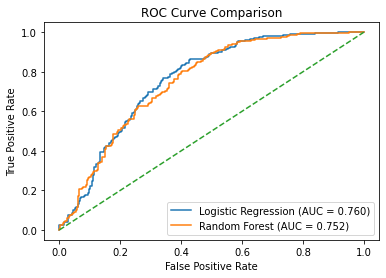

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_val, y_proba_lr)
auc_lr = roc_auc_score(y_val, y_proba_lr)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_val, y_proba_rf)
auc_rf = roc_auc_score(y_val, y_proba_rf)

# Plot
plt.figure()

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')

# Diagonal line (random model)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')

plt.legend()
plt.show()

The ROC curves illustrate the trade-off between true positive rate and false positive rate for both models. Logistic Regression achieves a slightly higher AUC compared to Random Forest, indicating better overall discrimination between churned and active customers.

This result is consistent with previous evaluation metrics, reinforcing the selection of Logistic Regression as the preferred model.


## 11. Feature Importance

This step extracts feature importance scores from the trained Random Forest model. These scores indicate how much each feature contributes to the model’s predictions, based on how effectively the feature reduces impurity across all trees in the forest. The features are ranked in descending order to identify the most influential variables in predicting customer churn.

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importance
importances = rf_model.feature_importances_
features = X.columns

feat_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_importance)

     Feature  Importance
2   Monetary    0.438900
0    Recency    0.317979
1  Frequency    0.243121


The feature importance plot visualizes the relative contribution of each RFM feature to the Random Forest model. Features with higher importance values play a greater role in reducing impurity during tree splits, indicating stronger influence on churn predictions.

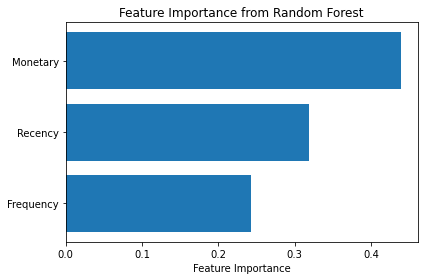

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Create importance Series
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values()

# Plot
plt.figure(figsize=(6, 4))
plt.barh(importance.index, importance.values)
plt.xlabel('Feature Importance')
plt.title('Feature Importance from Random Forest')
plt.tight_layout()
plt.show()

Feature importance analysis reveals that Monetary value is the most influential predictor of customer churn, followed by Recency and Frequency.

This indicates that customer spending behavior is a key signal in distinguishing churned and active customers, providing stronger predictive power than purchase frequency or recency alone.

From a business perspective, this suggests that customer value should be a key focus in churn prevention strategies. High-value customers who are at risk of churn should be prioritized, as losing them would have a greater financial impact.

Targeted retention strategies, such as personalized offers or loyalty incentives, can be particularly effective for these customers.


## 12. Conclusion

In this project, customer churn was analyzed using transactional online retail data by transforming purchase records into meaningful customer-level features through RFM analysis. A time-based split and forward-looking labeling strategy were applied to simulate a real-world prediction scenario and prevent data leakage.

Two machine learning models, Logistic Regression and Random Forest, were trained and evaluated using metrics such as ROC-AUC and recall. The results showed that Logistic Regression slightly outperformed Random Forest and achieved significantly higher recall for churned customers.

Given the business objective of identifying at-risk customers, recall was prioritized as a key metric. Therefore, Logistic Regression was selected as the preferred model for churn prediction.

Feature importance analysis further revealed that customer spending behavior (Monetary) plays a critical role in predicting churn, highlighting the importance of customer value in retention strategies.

Overall, this project demonstrates how behavioral features and appropriate evaluation strategies can be leveraged to build effective churn prediction models in a non-contractual retail setting.


## 13. Future Work

Future improvements can focus on enhancing both model performance and business impact. Potential directions include:

   - Applying threshold optimization to better balance precision and recall based on business objectives.

   - Exploring more advanced models such as Gradient Boosting (e.g., XGBoost or LightGBM).

   - Incorporating additional behavioral features, such as customer lifetime value or time between purchases.

   - Using cross-validation techniques adapted for time series data.

   - Applying model interpretability techniques (e.g., SHAP values) for deeper insights into customer behavior.

These improvements can help build more robust, interpretable, and actionable churn prediction systems.